In [36]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


엑셀 파일을 업로드하세요.


Saving data.xlsx to data (29).xlsx

데이터 확인
          날짜  마케팅 비용(원)   매출액(원)
0 2026-08-01    1000000  5200000
1 2026-08-02    5000000  5150000
2 2026-08-03    1200000  5300000
3 2026-08-04    1000000  5800000
4 2026-08-05    1100000  7500000

시차별 상관계수
   시차(일)    상관계수
0      0 -0.3602
1      1 -0.3716
2      2 -0.2103
3      3  0.7951
4      4  0.1816
5      5     NaN

최적 시차 : 3 일
최대 상관계수 : 0.7951


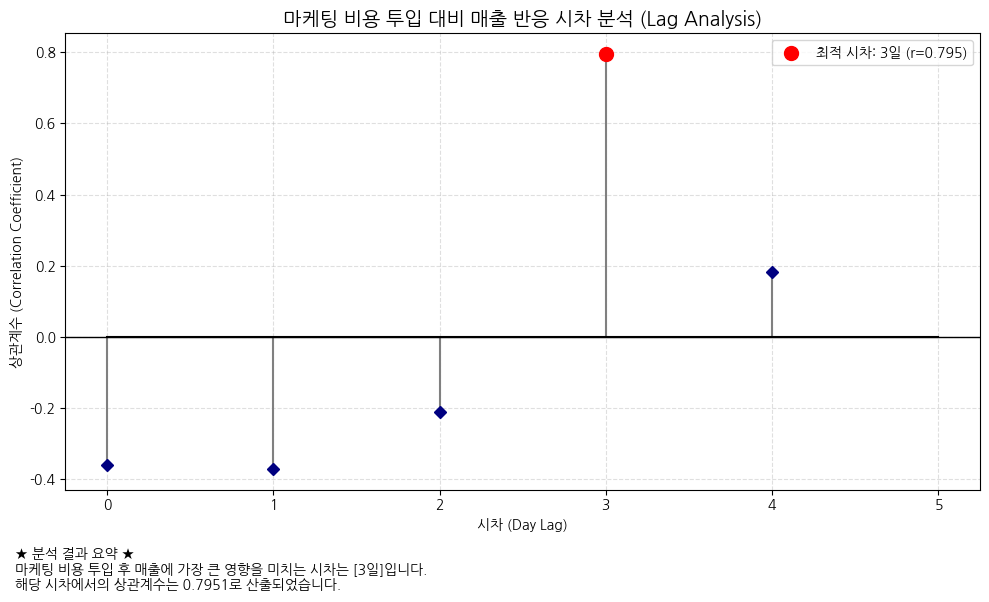

In [46]:
# ==========================================================
# 마케팅 비용 → 매출 반응 시차 분석 (Lag Analysis)
# Google Colab 업로드 버전
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
import platform

# ==========================================================
# 한글 폰트
# ==========================================================

!apt-get -qq install fonts-nanum > /dev/null

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================================
# 파일 업로드
# ==========================================================

print("엑셀 파일을 업로드하세요.")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_excel(io.BytesIO(uploaded[filename]))

print("\n데이터 확인")
print(df.head())

# ==========================================================
# 컬럼 자동 인식
# ==========================================================
# 3개 이상 컬럼
# A : 날짜
# B : 마케팅비용
# C : 매출액

if df.shape[1] >= 3:

    marketing = pd.to_numeric(
        df.iloc[:,1],
        errors='coerce'
    )

    sales = pd.to_numeric(
        df.iloc[:,2],
        errors='coerce'
    )

# 2개 컬럼
# A : 마케팅비용
# B : 매출액

elif df.shape[1] == 2:

    marketing = pd.to_numeric(
        df.iloc[:,0],
        errors='coerce'
    )

    sales = pd.to_numeric(
        df.iloc[:,1],
        errors='coerce'
    )

else:
    raise Exception("컬럼이 2개 이상 필요합니다.")

# ==========================================================
# 결측 제거
# ==========================================================

temp = pd.DataFrame({
    'marketing': marketing,
    'sales': sales
}).dropna()

marketing = temp['marketing']
sales = temp['sales']

# ==========================================================
# 시차분석
# ==========================================================

max_lag = min(6, len(temp)-2)

lags = []
corrs = []

for lag in range(max_lag+1):

    shifted_sales = sales.shift(-lag)

    temp2 = pd.DataFrame({
        'marketing': marketing,
        'sales': shifted_sales
    }).dropna()

    if len(temp2) >= 3:
        corr = temp2['marketing'].corr(temp2['sales'])
    else:
        corr = np.nan

    lags.append(lag)
    corrs.append(corr)

# ==========================================================
# 최적 시차
# ==========================================================

best_idx = np.nanargmax(corrs)

best_lag = lags[best_idx]
best_corr = corrs[best_idx]

# ==========================================================
# 결과표
# ==========================================================

result = pd.DataFrame({
    '시차(일)': lags,
    '상관계수': np.round(corrs,4)
})

print("\n시차별 상관계수")
print(result)

print("\n최적 시차 :", best_lag, "일")
print("최대 상관계수 :", round(best_corr,4))

# ==========================================================
# Stem Plot
# ==========================================================

fig, ax = plt.subplots(figsize=(10,6))

markerline, stemlines, baseline = ax.stem(
    lags,
    corrs,
    linefmt='gray',
    markerfmt='D',
    basefmt='black'
)

plt.setp(
    markerline,
    markersize=6,
    markerfacecolor='navy',
    markeredgecolor='navy'
)

# 최적 시차 빨간 점

ax.scatter(
    best_lag,
    best_corr,
    color='red',
    s=100,
    zorder=10,
    label=f'최적 시차: {best_lag}일 (r={best_corr:.3f})'
)

ax.axhline(
    0,
    color='black',
    linewidth=1
)

ax.set_title(
    '마케팅 비용 투입 대비 매출 반응 시차 분석 (Lag Analysis)',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('시차 (Day Lag)')
ax.set_ylabel('상관계수 (Correlation Coefficient)')

ax.set_xticks(lags)

ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

ax.legend(loc='upper right')

# ==========================================================
# 하단 요약
# ==========================================================

summary = (
    f"★ 분석 결과 요약 ★\n"
    f"마케팅 비용 투입 후 매출에 가장 큰 영향을 미치는 시차는 "
    f"[{best_lag}일]입니다.\n"
    f"해당 시차에서의 상관계수는 {best_corr:.4f}로 산출되었습니다."
)

plt.figtext(
    0.02,
    0.01,
    summary,
    fontsize=10
)

plt.tight_layout(rect=[0,0.08,1,1])

plt.show()